# 2-4. 상관분석

일별 금값, 은값, 달러 환율 사이의 관계를 확인한다.

- Pearson 상관분석으로 선형 관계를 확인한다.
- Spearman 상관분석으로 순위에 기반한 단조 관계를 확인한다.
- 상관관계는 인과관계를 의미하지 않는다.

## 이 실습의 학습 기준

이 노트북은 한 가지 함수의 결과만 확인하지 않고 다음 흐름으로 학습한다.

1. 데이터 구조에 맞는 검정 방법과 가정을 확인한다.
2. 같은 목적의 방법이 여러 개면 모두 실행해 결과를 비교한다.
3. 일부러 적합하지 않은 방법도 비교할 때는, 왜 최종 결론에 사용하지 않는지 밝힌다.
4. 전제검정 결과가 본 검정 선택에 어떻게 연결되는지 확인한다.
5. p-value뿐 아니라 차이의 방향과 크기까지 해석한다.
6. p-value가 `0.0000`으로 보이는 것은 반올림 결과이며, 실제 확률이 0이라는 뜻은 아니다.
7. 유의수준 α=0.05에서 `p-value < 0.05`면 귀무가설을 기각하고, `p-value >= 0.05`면 귀무가설을 기각하지 못한다.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

prices_df = pd.read_excel("datas2/일별_금은달러.xlsx")

print(prices_df.head())
print(prices_df.columns)

           일자        금값     은값   달러 환율
0  2020.08.07  78538.90  27.53  1188.5
1  2020.08.06  78009.22  28.39  1185.5
2  2020.08.05  77748.00  26.88  1188.0
3  2020.08.04  75873.57  26.01  1194.5
4  2020.08.03  75761.76  24.39  1195.7
Index(['일자', '금값', '은값', '달러 환율'], dtype='str')


## 1. 상관분석 데이터 확인

금값, 은값, 달러 환율은 모두 연속형 수치 데이터다. 결측값과 변수 범위를 먼저 확인한다.

In [2]:
price_columns = ["금값", "은값", "달러 환율"]
price_data = prices_df[price_columns]

print("열별 결측값 개수")
print(price_data.isna().sum())

print("\n기초 통계량")
print(price_data.describe().round(2))

열별 결측값 개수
금값       0
은값       0
달러 환율    0
dtype: int64

기초 통계량
             금값     은값    달러 환율
count     28.00  28.00    28.00
mean   72081.84  21.83  1197.72
std     3309.33   3.14     5.46
min    68269.27  18.13  1185.50
25%    69744.95  19.06  1194.88
50%    70117.34  20.81  1197.00
75%    75110.48  24.28  1203.00
max    78538.90  28.39  1206.50


## 2. Pearson 분석 전 KS-test와 Shapiro-Wilk 비교

각 변수의 정규성을 두 방법으로 확인한다. 이 검정은 Pearson 상관분석의 가정을 이해하기 위한 사전 점검이다.

- KS-test는 표본에서 평균과 표준편차를 추정한 학습용 비교다.
- Shapiro-Wilk를 작은 표본의 주 정규성 판단으로 사용한다.
- 변수별 정규성만으로 두 변수의 결합분포가 정규분포라는 사실까지 보장하지는 않는다.
- Pearson 추론에서는 선형성, 극단적 이상치, 관측치 독립성도 함께 확인해야 한다.

In [3]:
price_normality_rows = []

for column in price_columns:
    values = price_data[column].to_numpy()
    ks_result = stats.kstest(
        values,
        stats.norm.cdf,
        args=(np.mean(values), np.std(values, ddof=1))
    )
    shapiro_result = stats.shapiro(values)

    price_normality_rows.extend([
        {
            "변수": column,
            "검정 방법": "KS-test",
            "검정통계량": ks_result.statistic,
            "p-value": ks_result.pvalue
        },
        {
            "변수": column,
            "검정 방법": "Shapiro-Wilk",
            "검정통계량": shapiro_result.statistic,
            "p-value": shapiro_result.pvalue
        }
    ])

price_normality_comparison = pd.DataFrame(price_normality_rows)
price_normality_comparison["결론"] = price_normality_comparison["p-value"].apply(
    lambda p: "정규성 위반 증거 부족" if p >= 0.05 else "정규성 위반 가능성"
)

display(price_normality_comparison.round(4))

,변수,검정 방법,검정통계량,p-value,결론
0,금값,KS-test,0.2581,0.0393,정규성 위반 가능성
1,금값,Shapiro-Wilk,0.8747,0.0031,정규성 위반 가능성
2,은값,KS-test,0.2143,0.1315,정규성 위반 증거 부족
3,은값,Shapiro-Wilk,0.8946,0.0086,정규성 위반 가능성
4,달러 환율,KS-test,0.1189,0.7805,정규성 위반 증거 부족
5,달러 환율,Shapiro-Wilk,0.9607,0.3617,정규성 위반 증거 부족


### 정규성 검정 비교에서 확인할 점

- 금값은 두 검정 모두 정규성 위반 가능성을 보인다.
- 은값은 KS-test와 Shapiro-Wilk의 결론이 다르다. 작은 표본에 더 민감한 Shapiro-Wilk 결과를 중심으로 보면 정규성 위반 가능성이 있다.
- 달러 환율은 두 검정 모두 정규성 위반의 충분한 증거를 보이지 않는다.

따라서 Pearson만 보고 끝내지 않고, 정규분포 가정의 영향을 덜 받는 Spearman 결과도 함께 비교한다.

## 3. 산점도로 관계 형태 확인

Pearson은 선형 관계, Spearman은 순위가 일정하게 증가하거나 감소하는 단조 관계를 측정한다. 산점도로 방향, 선형성, 이상치를 먼저 확인한다.

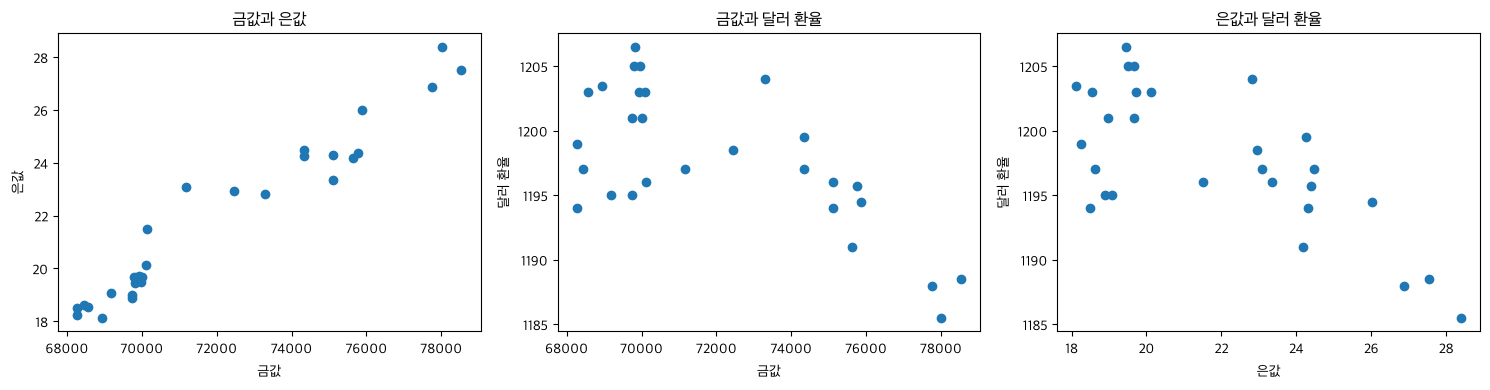

In [4]:
pairs = [
    ("금값", "은값", "금값과 은값"),
    ("금값", "달러 환율", "금값과 달러 환율"),
    ("은값", "달러 환율", "은값과 달러 환율")
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis, (x_column, y_column, title) in zip(axes, pairs):
    axis.scatter(prices_df[x_column], prices_df[y_column])
    axis.set_xlabel(x_column)
    axis.set_ylabel(y_column)
    axis.set_title(title)

plt.tight_layout()
plt.show()

## 4. Pearson 상관분석

- 귀무가설(H₀): 두 변수의 모집단 Pearson 상관계수는 0이다.
- 대립가설(H₁): 두 변수의 모집단 Pearson 상관계수는 0이 아니다.

In [5]:
pearson_results = []

for x_column, y_column, _ in pairs:
    result = stats.pearsonr(prices_df[x_column], prices_df[y_column])
    pearson_results.append({
        "비교": f"{x_column} - {y_column}",
        "Pearson 계수": result.statistic,
        "Pearson p-value": result.pvalue
    })

pearson_summary = pd.DataFrame(pearson_results)
display(pearson_summary.round(4))

,비교,Pearson 계수,Pearson p-value
0,금값 - 은값,0.9719,0.0000
1,금값 - 달러 환율,-0.6793,0.0001
2,은값 - 달러 환율,-0.6955,0.0000


## 5. Spearman 상관분석

Spearman은 실제 값 대신 순위를 사용한다. 비정규분포와 이상치의 영향을 Pearson보다 덜 받으며 단조 관계를 확인한다.

- 귀무가설(H₀): 두 변수의 모집단 Spearman 상관계수는 0이다.
- 대립가설(H₁): 두 변수의 모집단 Spearman 상관계수는 0이 아니다.

In [6]:
spearman_results = []

for x_column, y_column, _ in pairs:
    result = stats.spearmanr(prices_df[x_column], prices_df[y_column])
    spearman_results.append({
        "비교": f"{x_column} - {y_column}",
        "Spearman 계수": result.statistic,
        "Spearman p-value": result.pvalue
    })

spearman_summary = pd.DataFrame(spearman_results)
display(spearman_summary.round(4))

,비교,Spearman 계수,Spearman p-value
0,금값 - 은값,0.9711,0.0000
1,금값 - 달러 환율,-0.5039,0.0063
2,은값 - 달러 환율,-0.5281,0.0039


## 6. Pearson과 Spearman 결과 비교

두 방법의 계수 크기, 방향, 유의성 결론을 같은 표에서 비교한다. 정규성 점검 결과 때문에 Spearman을 보완적으로 중요하게 해석하되, 산점도에서 선형 관계도 보이므로 Pearson 결과도 함께 보고한다.

In [7]:
correlation_comparison = pearson_summary.merge(
    spearman_summary,
    on="비교"
)

correlation_comparison["방향 일치"] = (
    np.sign(correlation_comparison["Pearson 계수"])
    == np.sign(correlation_comparison["Spearman 계수"])
)
correlation_comparison["유의성 결론 일치"] = (
    (correlation_comparison["Pearson p-value"] < 0.05)
    == (correlation_comparison["Spearman p-value"] < 0.05)
)

display(correlation_comparison.round(4))

,비교,Pearson 계수,Pearson p-value,Spearman 계수,Spearman p-value,방향 일치,유의성 결론 일치
0,금값 - 은값,0.9719,0.0000,0.9711,0.0000,True,True
1,금값 - 달러 환율,-0.6793,0.0001,-0.5039,0.0063,True,True
2,은값 - 달러 환율,-0.6955,0.0000,-0.5281,0.0039,True,True


In [8]:
pearson_matrix = price_data.corr(method="pearson")
spearman_matrix = price_data.corr(method="spearman")

print("Pearson 상관계수 행렬")
display(pearson_matrix.round(4))

print("Spearman 상관계수 행렬")
display(spearman_matrix.round(4))

Pearson 상관계수 행렬


,금값,은값,달러 환율
금값,1.0000,0.9719,-0.6793
은값,0.9719,1.0000,-0.6955
달러 환율,-0.6793,-0.6955,1.0000


Spearman 상관계수 행렬


,금값,은값,달러 환율
금값,1.0000,0.9711,-0.5039
은값,0.9711,1.0000,-0.5281
달러 환율,-0.5039,-0.5281,1.0000


## 7. 분석 결과

- 금값과 은값은 Pearson 0.9719, Spearman 0.9711로 두 방법 모두 매우 강한 양의 관계를 보였다.
- 금값과 달러 환율은 Pearson -0.6793, Spearman -0.5039로 유의한 음의 관계를 보였다.
- 은값과 달러 환율은 Pearson -0.6955, Spearman -0.5281로 유의한 음의 관계를 보였다.
- 세 쌍 모두 관계 방향과 유의성 결론은 같았지만, Pearson과 Spearman의 계수 크기는 달랐다.
- 금값과 은값의 Shapiro-Wilk 결과에서 정규성 위반 가능성이 확인되므로 Spearman 결과가 중요한 보완 근거가 된다.
- 같은 날짜가 이어지는 시계열 자료이므로 관측치 독립성이 약할 수 있고, 공통 시간 흐름이나 외부 요인이 상관계수에 영향을 주었을 수 있다.
- 상관관계는 한 변수가 다른 변수를 직접 변화시켰다는 인과관계를 뜻하지 않는다.